In [2]:
import example_loader as el
import gurobipy as gp
import gurobi_utils as gu
import miplib_loader as ml
import numpy as np
import plot_utils as pu

In [3]:
# configure the backend for matplotlib
# this one should allow zoom:
# %matplotlib widget
# to make that work you need: "pip install ipympl" and run "jupyter nbextension enable --py widgetsnbextension"

# this will work without the above dependencies but won't allow zoom
%matplotlib inline

# this option may work whenever they fix bugs in mpld3
# import mpld3
# mpld3.enable_notebook()

Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Running model: 2D from bottom (manual slack on 2)
   Relaxed 2 variables on 2D from bottom (manual slack on 2)
   Loop: 1 , Relaxed sc

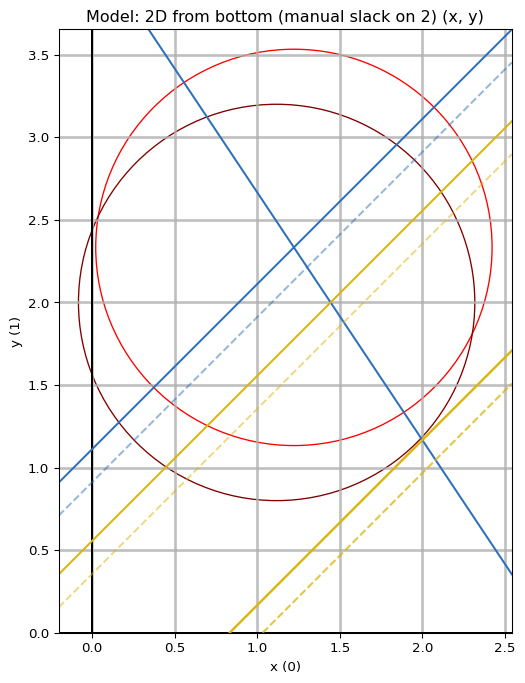

Running model: 2D from bottom (manual slacks)
   Relaxed 2 variables on 2D from bottom (manual slacks)
   Loop: 1 , Relaxed score: 2.3333333333333335
1.9999999999999991 sa1 + 1.9999999999999991 sa2
0.5714285714285713 sa1 + 3.000000000000002 sa2
   Loop: 2 , Relaxed score: 2.0
-0.37500000000000033 + 9.999999999999975 sa1 + 0.7500000000000003 sa1 + 0.7500000000000003 sa2
   Loop: 3 , Relaxed score: 2.0
   Done! All constraints met.
   Known best score: 2


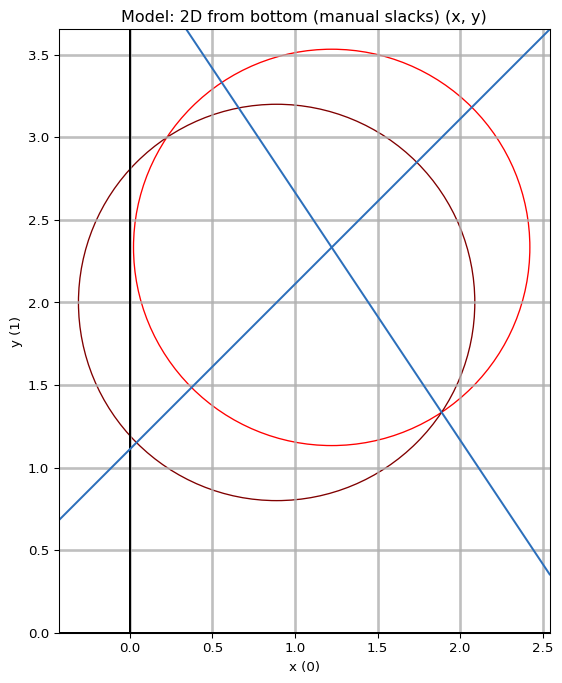

Running model: 2D from bottom (manual slack, just one)
   Relaxed 1 variables on 2D from bottom (manual slack, just one)
   Loop: 1 , Relaxed score: 2.7
1.4285714285714282 s1
   Loop: 2 , Relaxed score: 2.0
   Done! All constraints met.
   Known best score: 2


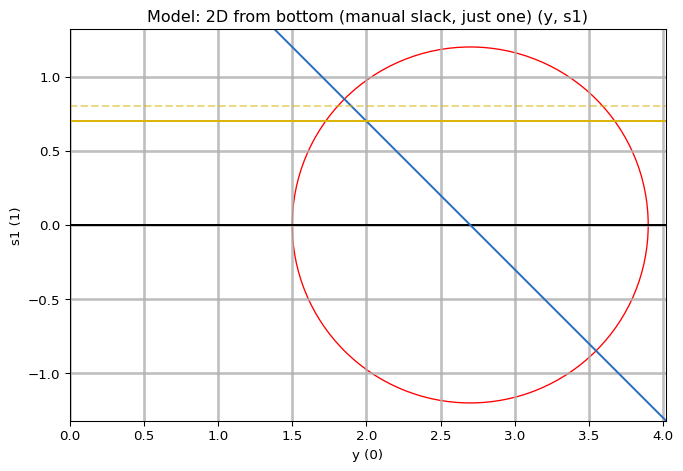

In [17]:
# A function to create cuts given a target point
def add_cut(relaxed: gp.Model, integer_vars, integer_idx, plotter):
    
    tol = relaxed.params.FeasibilityTol
    all_done = True
    for iv in integer_vars:
        x = iv.X.item()
        if not np.isclose(x, round(x), atol=tol):
            all_done = False
            break
    if all_done:
        return False
    
    if plotter is not None:
        plotter.add_ball(1.2)
    variables = relaxed.getVars()  # TODO: pass this in as it's expensive?
    constraints = relaxed.getConstrs()  # wish we didn't have to use this one
    
    def find_variable_value(index):
        if index < len(variables):
            if variables[index].VBasis == -2:
                raise NotImplementedError("handle vbasis")  # not yet sure what to do here
            return variables[index].X
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        try:
            return constraint.Slack
        except:
            return 0.0
    
    def find_variable(index):
        if index < len(variables):
            # handle inverted variables (SCIP and Gurobi both have this silliness)
            if variables[index].VBasis == -2:  # not yet sure this is correct
                return variables[index].UB - variables[index] 
            assert variables[index].VBasis != -3  # not handling -3 yet
            return variables[index].LB + variables[index]
        # if only gurobi gave us access to their slack variables...
        # instead, we have to solve for it:
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        lhs, sense, rhs = relaxed.getRow(constraint), constraint.Sense, constraint.RHS
        if sense == '<':
             return rhs - lhs
        elif sense == '>':
            return lhs - rhs
        else:
            return 0.0  # Gurobi has slacks on equality constraints, but they must always be 0
    
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=1)
    negated_vars = [basis[nr] for nr in negated_rows]
    
    # drop the rows of non-integer variables:
    # to_drop = [i for i, base in enumerate(basis) if base not in integer_idx]
    # tableau = np.delete(tableau, to_drop, axis=0)
    # basis = np.delete(basis, to_drop)
                
    # the current understanding: 
    # negate all columns with variables at status -1
    # and negate all columns match slack variables of type <
    for i, j in enumerate(col_to_var_idx):
        if j < len(variables):
            if variables[j].VBasis == -1:
                tableau[:, i] = -tableau[:, i]
        else:
            constraint = constraints[j - len(variables)]
            if constraint.Sense != '>':  # still unsure on this one; can't tell what to do with equality 
                tableau[:, i] = -tableau[:, i]
        
    int_cols = [i for i, c in enumerate(col_to_var_idx) if c in integer_idx]
    tableau[-1, int_cols] = 1  # use our extra row to store the col==row -> 1
    
    col_to_var = [find_variable(c) for c in col_to_var_idx]
    
    # basis_corner = np.zeros(len(variables) + len(constraints))
    # for i in basis:
    #     basis_corner[i] = find_variable_value(i)
    to_cut = [(i, base, find_variable_value(base)) for i, base in enumerate(basis)  # can't call find_var_value after addConstr or update
              if base in integer_idx and tol < (integer_vars[integer_idx[base]].X % 1) < 1.0-tol]
    for row, base, x in reversed(to_cut):
        # print("      Adding cut for", base, x)
        points = []
        for col, ray in enumerate(tableau.T):
            rr = ray[row]
            # if row in negated_rows:
            #     rr = -rr
            if np.isclose(rr, 0, atol=tol):
                continue
            scale = -(x % 1) / rr if rr < 0 else (1-(x % 1)) / rr
            # print("SCALE", scale, x, rr)
            # point = basis_corner.copy()
            # point[basis] += scale * ray[:-1]
            # point[r] += scale * ray[-1]
            # print("INFO", row, col, base, x, ray, scale)
            
            points.append((col_to_var[col], 1.0/scale))
            #  left off: how to handle the zero-case? I need it to take a bigger step in s1? It does okay on the second step. 
            # what line do I really want there?
        # a = np.vstack(points)
        # y, _, _, _ = np.linalg.lstsq(a, np.zeros(a.shape[0]), rcond=tol)
        # left off: our old code probably handled distance down the ray; we need that. See if it was ball-dependant.
        # and also see if it drew the correct thing, and what space it drew in.
        summed_terms = gp.quicksum(nrm * v for v, nrm in points)
        if len(variables) < 5:
            print(str(summed_terms))
        new_con = relaxed.addConstr(summed_terms >= 1)

        # yd = np.linalg.det(a)
        # y = np.linalg.pinv(a, rcond=tol) @ np.ones(a.shape[0])
        # 
        # we assume order variables then slacks and that our point has all variables in it:
        
        # summed_terms = y[:len(variables)] @ variables + y[len(variables):-1] @ slack_variables
            
        if plotter is not None:
            relaxed.update()
            plotter.add_constraint(new_con)
        # break  # remove this and the reversed when done debugging
            
    return True

def run_cuts_to_relaxed_sol(instances, loops=1):
    for instance in instances:
        model: gp.Model = instance.as_gurobi_model()
        print("Running model:", model.ModelName)
        model.params.LogToConsole = 0
        model.update()
        plotter = pu.create(model)
        int_vars, int_idx = gu.relax_int_or_bin_to_continuous(model)
        # gu.standardize_lt_to_gt(model)
        # gu.standardize_eq_to_gt(model)

        for i in range(loops):
            model.optimize()
            if model.Status != gp.GRB.OPTIMAL:
                print("   FAILED! Status:", model.Status)
                break
                
            print("   Loop:", i+1, ", Relaxed score:", model.getObjective().getValue())
            # current = [(iv.VarName.item(), iv.X.item()) for iv in int_vars]
            # print("      Current:", current)
                
            if not add_cut(model, int_vars, int_idx, plotter):
                print("   Done! All constraints met.")
                break

        print("   Known best score:", instance.score if instance.known_optimum else "unknown")    
        if plotter is not None:
            plotter.render()

# test the cuts on simple examples:
# run_cuts_to_relaxed_sol(list(el.get_instances().values())[1:2], loops=5)
run_cuts_to_relaxed_sol(list(el.get_instances().values())[6:], loops=5)

In [18]:
import jsplib_loader as jl
jsplib_instances = jl.get_instances()
jsplib_subset = [jsplib_instances['abz4']]
run_cuts_to_relaxed_sol(jsplib_subset, loops=20)

Set parameter AggFill to value 10
Set parameter GomoryPasses to value 1
Running model: abz4
   Relaxed 216 variables on abz4
   Loop: 1 , Relaxed score: 505.0
   Loop: 2 , Relaxed score: 508.15676449534715
   Loop: 3 , Relaxed score: 589.0004862207682
   Loop: 4 , Relaxed score: 589.1902629333423
   Loop: 5 , Relaxed score: 600.4903954676315
   Loop: 6 , Relaxed score: 606.017566283357
   Loop: 7 , Relaxed score: 607.202175791998
   Loop: 8 , Relaxed score: 608.3607646973314
   Loop: 9 , Relaxed score: 609.375866037847
   Loop: 10 , Relaxed score: 609.6928861921313
   Loop: 11 , Relaxed score: 609.8541372631923
   Loop: 12 , Relaxed score: 609.9811746955938
   Loop: 13 , Relaxed score: 610.0815471423889
   Loop: 14 , Relaxed score: 610.0890418787174
   Loop: 15 , Relaxed score: 610.1057886739419
   Loop: 16 , Relaxed score: 610.1486411290342
   Loop: 17 , Relaxed score: 610.1615980778884
   Loop: 18 , Relaxed score: 610.176173914178
   Loop: 19 , Relaxed score: 610.183144835565
   Loop